In [ ]:
# Run in Google Collab since its using Pre Trained Data CPU may not support.
# Change run Time to GPU in Google Collab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2025-05-19 14:22:52--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.25, 104.192.142.24, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105946856 (101M) [application/zip]
Saving to: ‘fruits.zip’

fruits.zip          100%[===================>] 101.04M  17.1MB/s    in 6.2s    

2025-05-19 14:22:59 (16.2 MB/s) - ‘fruits.zip’ saved [105946856/105946856]



In [2]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [5]:
tf.__version__

'2.18.0'

In [6]:
img_height,img_width=32,32
batch_size=20
train_ds=tf.keras.utils.image_dataset_from_directory("fruits/train",image_size=(img_height,img_width),batch_size=batch_size)
validation_ds=tf.keras.utils.image_dataset_from_directory("fruits/validation",image_size=(img_height,img_width),batch_size=batch_size)
test_ds=tf.keras.utils.image_dataset_from_directory("fruits/test",image_size=(img_height,img_width),batch_size=batch_size)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


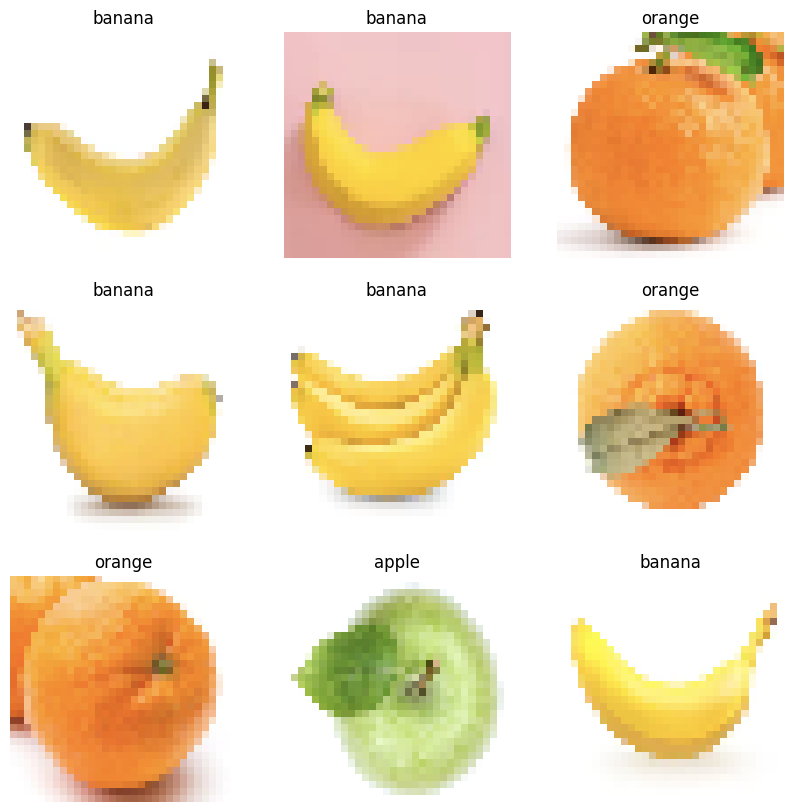

In [7]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [12]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="softmax"),
     tf.keras.layers.Dense(3)
    ]
)

In [13]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [15]:
model.fit(
    train_ds,
    validation_data = validation_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.3353 - loss: 1.0981 - val_accuracy: 0.3485 - val_loss: 1.0969
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.3976 - loss: 1.0959 - val_accuracy: 0.4091 - val_loss: 1.0673
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.4346 - loss: 1.0747 - val_accuracy: 0.5455 - val_loss: 1.0146
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6145 - loss: 1.0112 - val_accuracy: 0.6667 - val_loss: 0.9808
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6888 - loss: 0.9763 - val_accuracy: 0.8030 - val_loss: 0.9290
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7443 - loss: 0.9397 - val_accuracy: 0.7424 - val_loss: 0.9143
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8015 - loss: 0.9027 - val_accuracy: 0.7121 - val_loss: 0.9174
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.8048 - loss: 0.8808 - val_accuracy: 0.8939 -

In [16]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9240 - loss: 0.6135


[0.5999165177345276, 0.9384615421295166]

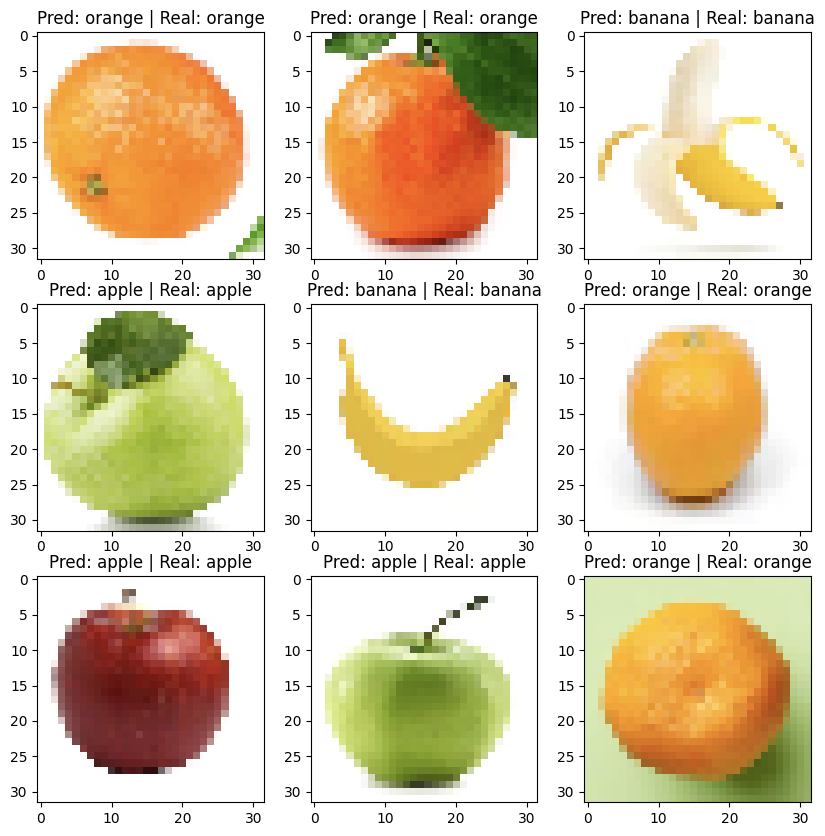

In [17]:
import numpy

plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  # print(classifications)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [18]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpoi8wz_tz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133004953562064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953565904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953564944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953555152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953554768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953557840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953566288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004953567056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004952601040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133004952602000: TensorSpec(shape=(), dtype=tf.resource, name=None)
